In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\DELL\OneDrive\Documents\Spotify case study\spotify_churn_dataset.csv")
df

,user_id,subscription_type,country,avg_daily_minutes,number_of_playlists,top_genre,skips_per_day,support_tickets,days_since_last_login,churned
0,user_1,Premium,US,134.9,4,Electronic,6,0,1,0
1,user_2,Premium,PK,165.7,5,Pop,8,0,12,0
2,user_3,Free,DE,45.9,3,Classical,3,0,3,0
3,user_4,Premium,PK,106.0,0,Jazz,7,0,3,0
4,user_5,Premium,US,89.6,5,Country,2,1,6,0
...,...,...,...,...,...,...,...,...,...,...
995,user_996,Free,IN,47.6,5,Hip-Hop,5,0,27,1
996,user_997,Premium,BR,115.1,5,Country,2,0,4,0
997,user_998,Premium,FR,89.5,6,Classical,0,0,1,0
998,user_999,Free,AU,33.2,3,Classical,5,0,15,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                1000 non-null   object 
 1   subscription_type      1000 non-null   object 
 2   country                1000 non-null   object 
 3   avg_daily_minutes      1000 non-null   float64
 4   number_of_playlists    1000 non-null   int64  
 5   top_genre              1000 non-null   object 
 6   skips_per_day          1000 non-null   int64  
 7   support_tickets        1000 non-null   int64  
 8   days_since_last_login  1000 non-null   int64  
 9   churned                1000 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 78.3+ KB


In [4]:
df.describe()

,avg_daily_minutes,number_of_playlists,skips_per_day,support_tickets,days_since_last_login,churned
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,97.442100,3.434000,4.631000,0.232000,9.496000,0.186000
std,42.916587,2.324015,2.777148,0.514238,9.742017,0.389301
min,-37.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,65.900000,1.000000,3.000000,0.000000,2.000000,0.000000
50%,97.900000,3.000000,5.000000,0.000000,7.000000,0.000000
75%,129.750000,5.000000,6.000000,0.000000,14.000000,0.000000
max,237.800000,10.000000,14.000000,2.000000,58.000000,1.000000


In [5]:
df.isnull().sum()

user_id                  0
subscription_type        0
country                  0
avg_daily_minutes        0
number_of_playlists      0
top_genre                0
skips_per_day            0
support_tickets          0
days_since_last_login    0
churned                  0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['subscription_type'].value_counts()

subscription_type
Premium    617
Free       383
Name: count, dtype: int64

In [12]:
df['country'].value_counts()

country
PK    105
RU    104
UK    101
CA    101
AU    101
DE    100
FR    100
IN     98
BR     96
US     94
Name: count, dtype: int64

In [14]:
df['top_genre'].value_counts()

top_genre
Country       163
Hip-Hop       153
Rock          147
Classical     145
Electronic    142
Jazz          130
Pop           120
Name: count, dtype: int64

In [15]:
df['churned'].value_counts()

churned
0    814
1    186
Name: count, dtype: int64

In [17]:
df["churned"].value_counts(normalize=True) * 100

churned
0    81.4
1    18.6
Name: proportion, dtype: float64

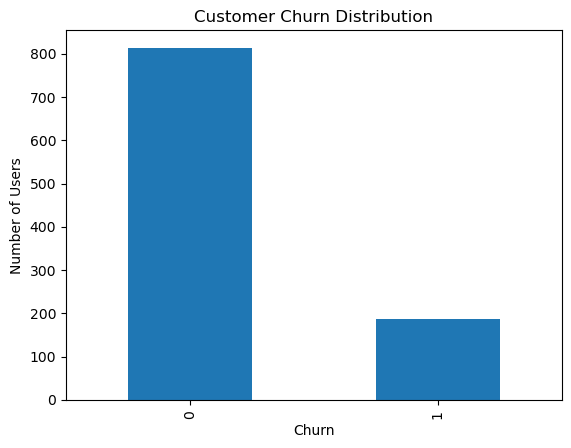

In [18]:
import matplotlib.pyplot as plt

df["churned"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Users")
plt.show()

In [19]:
pd.crosstab(df["subscription_type"], df["churned"])

churned,0,1
subscription_type,,
Free,248,135
Premium,566,51


In [20]:
pd.crosstab(
    df["subscription_type"],
    df["churned"],
    normalize="index"
) * 100

churned,0,1
subscription_type,,
Free,64.751958,35.248042
Premium,91.734198,8.265802


<Axes: xlabel='subscription_type'>

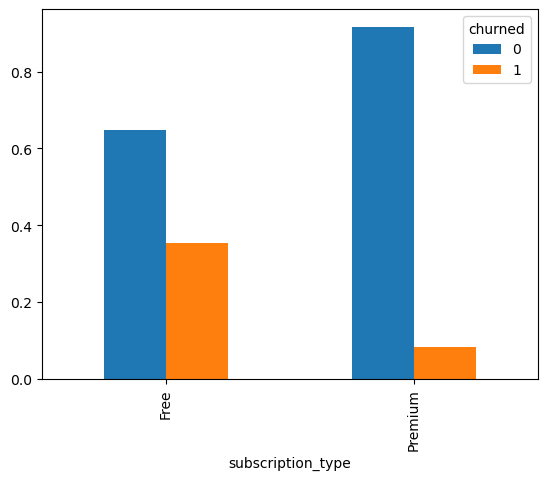

In [21]:
pd.crosstab(
    df["subscription_type"],
    df["churned"],
    normalize="index"
).plot(kind="bar")

In [22]:
df.groupby("churned")["avg_daily_minutes"].mean()

churned
0    103.272359
1     71.926882
Name: avg_daily_minutes, dtype: float64

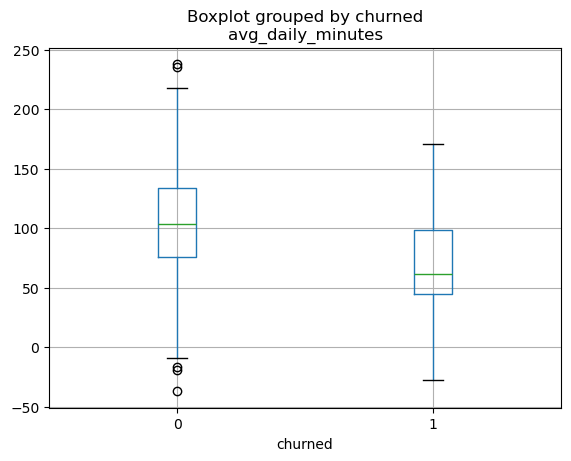

In [23]:
df.boxplot(column="avg_daily_minutes", by="churned")
plt.show()

In [24]:
df.groupby("churned")["number_of_playlists"].mean()

churned
0    3.632678
1    2.564516
Name: number_of_playlists, dtype: float64

In [25]:
df.groupby("churned")["skips_per_day"].mean()

churned
0    4.692875
1    4.360215
Name: skips_per_day, dtype: float64

In [26]:
df.groupby("churned")["support_tickets"].mean()

churned
0    0.183047
1    0.446237
Name: support_tickets, dtype: float64

In [27]:
df.groupby("churned")["days_since_last_login"].mean()

churned
0     8.841523
1    12.360215
Name: days_since_last_login, dtype: float64

In [28]:
pd.crosstab(df["country"], df["churned"])

churned,0,1
country,,
AU,74,27
BR,81,15
CA,79,22
DE,77,23
FR,84,16
IN,78,20
PK,89,16
RU,88,16
UK,91,10


In [29]:
pd.crosstab(df["top_genre"], df["churned"])

churned,0,1
top_genre,,
Classical,118,27
Country,130,33
Electronic,113,29
Hip-Hop,121,32
Jazz,102,28
Pop,108,12
Rock,122,25


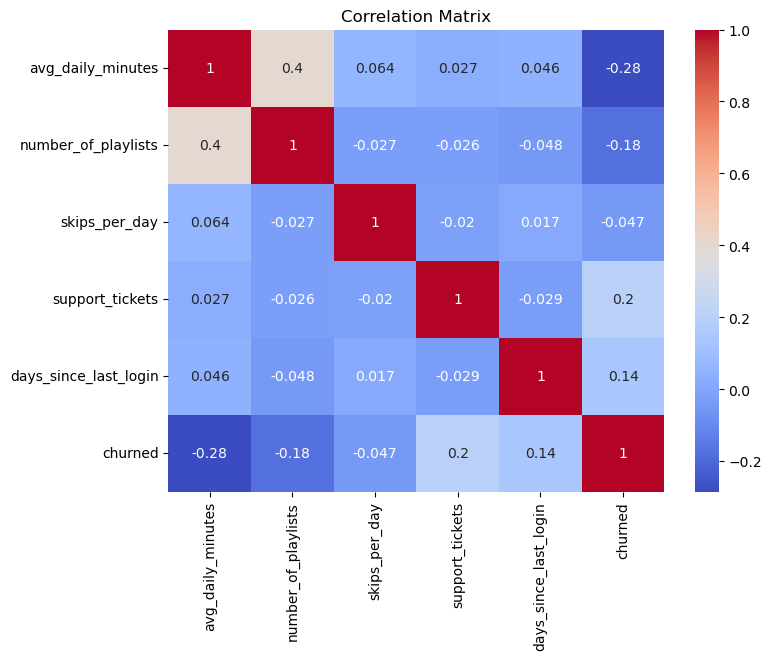

In [32]:
import seaborn as sns
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [34]:
pd.crosstab(
    df["country"],
    df["churned"],
    normalize="index"
) * 100

churned,0,1
country,,
AU,73.267327,26.732673
BR,84.375000,15.625000
CA,78.217822,21.782178
DE,77.000000,23.000000
FR,84.000000,16.000000
IN,79.591837,20.408163
PK,84.761905,15.238095
RU,84.615385,15.384615
UK,90.099010,9.900990


In [35]:
pd.crosstab(
    df["top_genre"],
    df["churned"],
    normalize="index"
) * 100

churned,0,1
top_genre,,
Classical,81.379310,18.620690
Country,79.754601,20.245399
Electronic,79.577465,20.422535
Hip-Hop,79.084967,20.915033
Jazz,78.461538,21.538462
Pop,90.000000,10.000000
Rock,82.993197,17.006803


In [36]:
pd.crosstab(
    [df["country"], df["subscription_type"]],
    df["churned"],
    normalize="index"
) * 100

churned                            0          1
country subscription_type                      
AU      Free               50.000000  50.000000
        Premium            89.830508  10.169492
BR      Free               66.666667  33.333333
        Premium            96.491228   3.508772
CA      Free               65.217391  34.782609
        Premium            89.090909  10.909091
DE      Free               53.846154  46.153846
        Premium            91.803279   8.196721
FR      Free               68.421053  31.578947
        Premium            93.548387   6.451613
IN      Free               55.555556  44.444444
        Premium            93.548387   6.451613
PK      Free               74.285714  25.714286
        Premium            90.000000  10.000000
RU      Free               73.809524  26.190476
        Premium            91.935484   8.064516
UK      Free               91.428571   8.571429
        Premium            89.393939  10.606061
US      Free               48.387097  51.612903
        Premium            92.063492   7.936508

In [37]:
df["engagement"] = pd.cut(
    df["avg_daily_minutes"],
    bins=[0,30,60,90,200],
    labels=["Low","Medium","High","Very High"]
)

In [38]:
pd.crosstab(
    df["engagement"],
    df["churned"],
    normalize="index"
) * 100

churned,0,1
engagement,,
Low,66.666667,33.333333
Medium,57.225434,42.774566
High,82.524272,17.475728
Very High,89.575972,10.424028


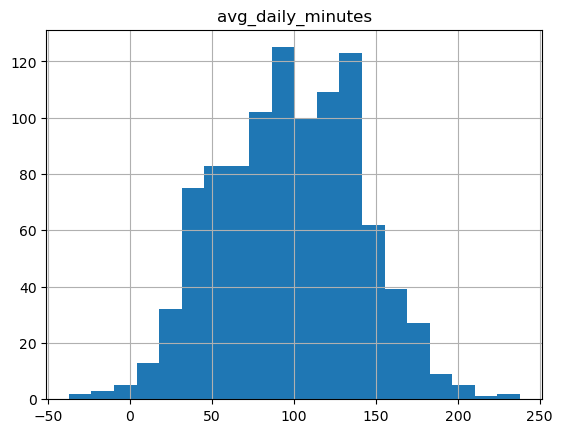

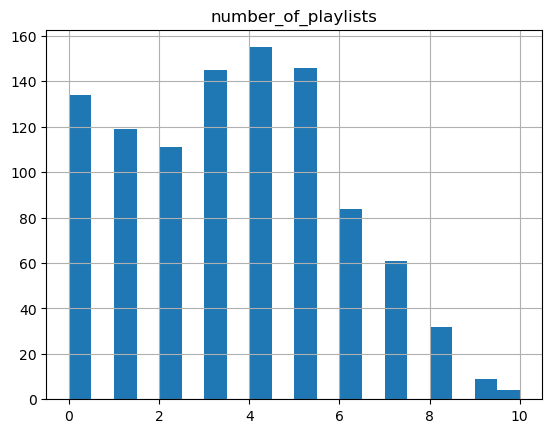

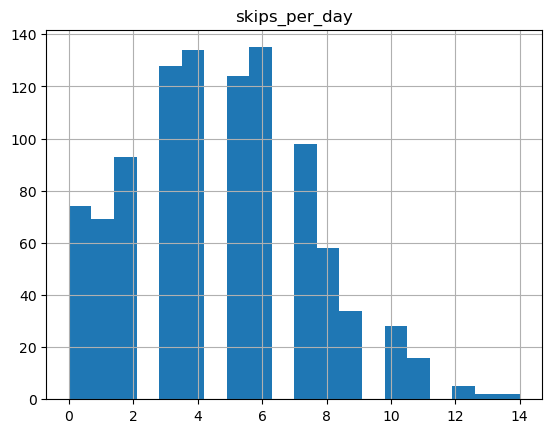

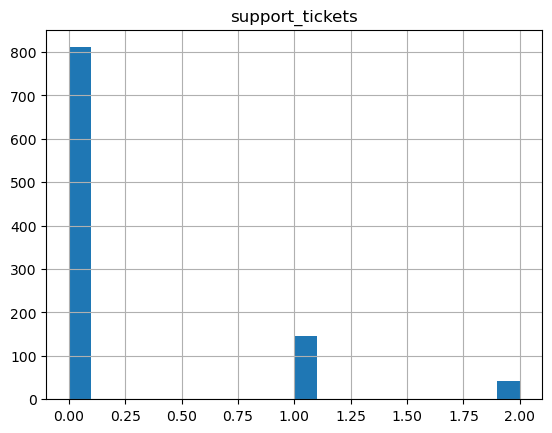

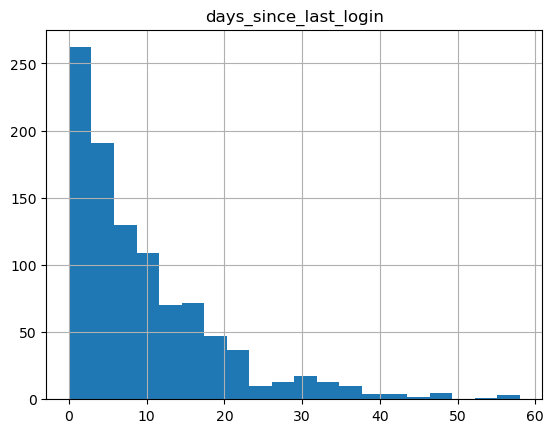

In [40]:
columns = [
    "avg_daily_minutes",
    "number_of_playlists",
    "skips_per_day",
    "support_tickets",
    "days_since_last_login"
]

for col in columns:
    df[col].hist(bins=20)
    plt.title(col)
    plt.show()

In [41]:
df.groupby('churned')[[
    'avg_daily_minutes',
    'number_of_playlists',
    'skips_per_day',
    'support_tickets',
    'days_since_last_login'
]].mean()

,avg_daily_minutes,number_of_playlists,skips_per_day,support_tickets,days_since_last_login
churned,,,,,
0,103.272359,3.632678,4.692875,0.183047,8.841523
1,71.926882,2.564516,4.360215,0.446237,12.360215


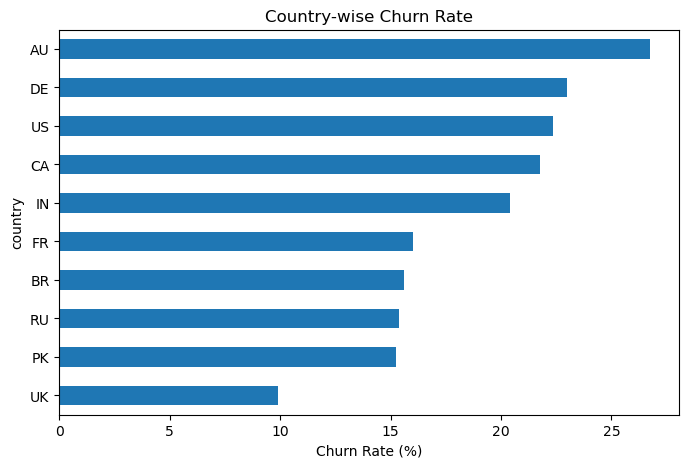

In [43]:
country_churn[1].sort_values().plot(kind='barh', figsize=(8,5))
plt.xlabel("Churn Rate (%)")
plt.title("Country-wise Churn Rate")
plt.show()

In [44]:
df['risk_score']=(
(df['days_since_last_login']>20).astype(int)+
(df['support_tickets']>2).astype(int)+
(df['avg_daily_minutes']<60).astype(int)+
(df['number_of_playlists']<3).astype(int)
)

In [45]:
df.groupby('risk_score')['churned'].mean()*100

risk_score
0     8.146640
1    23.708207
2    35.757576
3    60.000000
Name: churned, dtype: float64